In [15]:
import pysimdamicm

import ROOT

import pandas as pd
import numpy as np
from astropy.io import fits
import matplotlib
import matplotlib.pyplot as plt
import uproot

In [16]:
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.default"] = "regular"

In [17]:
file = "/home/dsalma/damicm-ml/img_8_stuff/panaSKImg_clustersRec_avg_Image_8_Low_Temp_106_20250923_093303_0_ext1.root"

In [18]:
with uproot.open(file) as f:
    print(f.keys())

['clustersRec;1', 'info;1', 'process_config;1']


In [19]:
clustersRec_tree = f["clustersRec"]

In [20]:
df2 = clustersRec_tree.arrays(library="pd")

In [21]:
try:
    import awkward as ak
except Exception:
    ak = None

def to_list_maybe(x):
    # Handle common array-likes
    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        return list(x)
    # Awkward arrays
    if ak is not None:
        try:
            return ak.to_list(x)
        except Exception:
            pass
    # Some awkward objects have .to_list()
    if hasattr(x, "to_list"):
        try:
            return x.to_list()
        except Exception:
            pass
    # Not an array -> return None so we can repeat later
    return None

# --- Choose columns (drop the blockers) ---
cols = [c for c in df2.columns if c not in ["RUNID", "Nclusters"]]

# Use the first row (you said there's 1 row)
row = df2.iloc[0]

# Find target length (e.g., 991) from the first array-like column
N = None
for c in cols:
    seq = to_list_maybe(row[c])
    if seq is not None:
        N = len(seq)
        break
if N is None:
    raise ValueError("Couldn't find any array-like columns to expand.")

# Build dict of columns -> sequences (repeat scalars)
data = {}
for c in cols:
    seq = to_list_maybe(row[c])
    if seq is None:
        # scalar: repeat it N times
        data[c] = [row[c]] * N
    else:
        data[c] = seq

df2_expanded = pd.DataFrame(data).reset_index(drop=True)

print(df2_expanded.shape)  
df2_expanded.head()

(3390, 56)


,DX,DY,Energy,Energy_AVG,Energy_PS,Npix,PosX,PosY,Qmax,QmaxX,...,readout_end,readout_start,seed_nsig_delta,seed_nsig_max,seed_nsig_min,seed_nsig_pixels,sigma_seed_eV,wSTD_X,wSTD_XY,wSTD_Y
0,16.0,7.0,5.249293,-1407.477905,1866.727173,77,278.286835,2.737540,0.288491,278.0,...,1.758643e+09,1.758613e+09,405.323029,415.400482,10.077470,"[10.176283836364746, 11.486743927001953, 53.68...",0.694488,2.424870,1.928515,1.248339
1,8.0,9.0,248.410278,86595.445312,88338.414062,41,328.515747,4.721443,20.910187,329.0,...,1.758643e+09,1.758613e+09,30098.103516,30108.787109,10.683082,"[155.2408905029297, 3276.407470703125, 8332.5,...",0.694488,0.948796,1.830961,2.409278
2,2.0,2.0,5.709201,1902.084717,2030.277344,3,1965.964233,415.003204,5.486501,1966.0,...,1.758643e+09,1.758613e+09,7873.755371,7900.067383,26.312252,"[294.3555603027344, 7900.0673828125, 26.312252...",0.694488,0.185807,0.137322,0.056484
3,11.0,4.0,0.323033,-1076.317993,114.875412,28,382.142700,2.407837,0.026439,383.0,...,1.758643e+09,1.758613e+09,27.892502,38.069534,10.177032,"[10.648303985595703, 16.25654411315918, 21.710...",0.694488,2.654646,2.026502,1.079944
4,20.0,14.0,65.885292,15908.962891,23429.794922,177,520.551270,5.214506,1.760694,520.0,...,1.758643e+09,1.758613e+09,2524.719727,2535.240723,10.520967,"[42.810977935791016, 143.8821258544922, 409.95...",0.694488,2.066094,2.735051,3.269903


In [22]:
df2_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 56 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DX                  3390 non-null   float64
 1   DY                  3390 non-null   float64
 2   Energy              3390 non-null   float64
 3   Energy_AVG          3390 non-null   float64
 4   Energy_PS           3390 non-null   float64
 5   Npix                3390 non-null   int64  
 6   PosX                3390 non-null   float64
 7   PosY                3390 non-null   float64
 8   Qmax                3390 non-null   float64
 9   QmaxX               3390 non-null   float64
 10  QmaxY               3390 non-null   float64
 11  RMSX                3390 non-null   float64
 12  RMSY                3390 non-null   float64
 13  STD_X               3390 non-null   float64
 14  STD_XY              3390 non-null   float64
 15  STD_Y               3390 non-null   float64
 16  closes

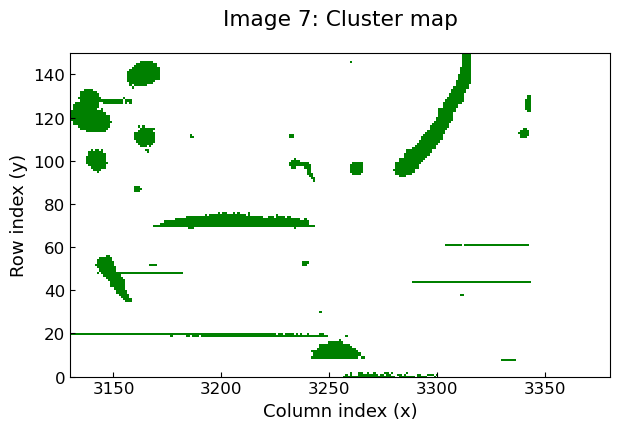

In [80]:
H, W = 500, 3500

# binary image: 1 = cluster pixel, 0 = background
img = np.zeros((H, W), dtype=int)

for _, row in df2_expanded.iterrows():
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    img[ys, xs] = 1

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["white", "green"])

plt.figure(figsize=(9, 4.5))
plt.imshow(img, origin="lower", cmap=cmap, interpolation="none")

plt.title("Image 7: Cluster map")
plt.xlabel("Column index (x)")
plt.ylabel("Row index (y)")

# zoom to requested CCD region
plt.xlim(3130, 3380)
plt.ylim(0, 150)

plt.tight_layout()
plt.show()

In [105]:
def cluster_energy_hist_in_window(
    df,
    x_range=(2090, 2210),
    y_range=(45, 125),
    bins=60,
    *,
    col_E="pixels_E",
    col_x="pixels_x",
    col_y="pixels_y",
    include_empty=False,
    density=False,
):
    """
    Histogram of CLUSTER energies within a CCD window.

    For each cluster (row):
      - select pixels inside the window
      - compute cluster energy = sum(pixel energies inside window)
      - histogram one value per cluster

    Clusters with no pixels in the window are excluded by default.
    """
    x0, x1 = x_range
    y0, y1 = y_range

    cluster_energies = []

    for _, row in df.iterrows():
        E = np.asarray(row[col_E])
        X = np.asarray(row[col_x])
        Y = np.asarray(row[col_y])

        if E.size == 0:
            if include_empty:
                cluster_energies.append(0.0)
            continue

        if not (E.shape == X.shape == Y.shape):
            raise ValueError(f"Shape mismatch: E{E.shape}, X{X.shape}, Y{Y.shape}")

        in_window = (X >= x0) & (X <= x1) & (Y >= y0) & (Y <= y1)
        E_w = E[in_window]

        if E_w.size == 0:
            if include_empty:
                cluster_energies.append(0.0)
            continue

        cluster_energies.append(float(np.sum(E_w)))

    cluster_energies = np.asarray(cluster_energies, dtype=float)

    plt.figure()
    plt.hist(cluster_energies, bins=bins, density=density)
    plt.xlabel("Cluster energy in CCD window (sum of pixel energies)")
    plt.ylabel("Density" if density else "Count (clusters)")
    plt.title(
        f"Cluster-energy histogram: x[{x0},{x1}], y[{y0},{y1}] "
        f"(N={cluster_energies.size})"
    )
    plt.show()

    return cluster_energies

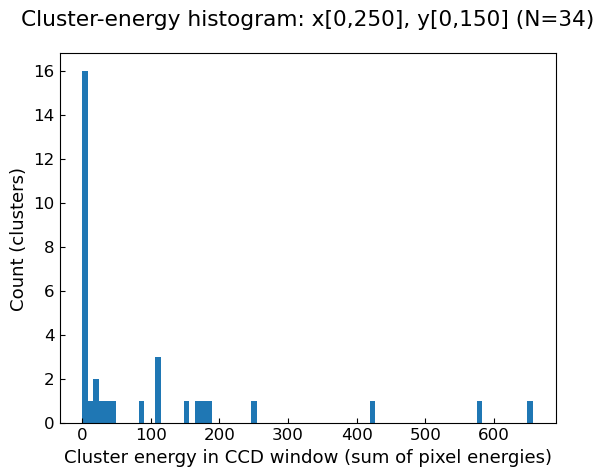

In [106]:
cluster_E = cluster_energy_hist_in_window(
    df2_expanded,
    x_range=(0, 250),
    y_range=(0, 150),
    bins=80
)

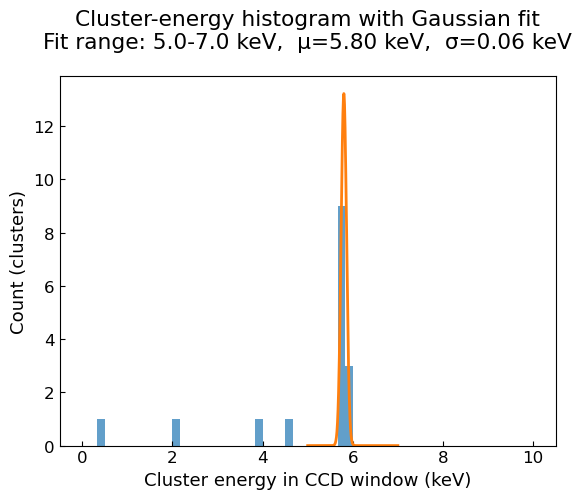

Gaussian fit results:
  mu    = 5.802 keV
  sigma = 0.060 keV
  N_fit = 12


In [107]:
from scipy.stats import norm

# cluster_energies is what your function returns
cluster_energies = np.asarray(cluster_E)

# --- fit range ---
fit_min, fit_max = 5.0, 7.0
fit_data = cluster_energies[
    (cluster_energies >= fit_min) & (cluster_energies <= fit_max)
]

# sanity check
if fit_data.size < 3:
    raise RuntimeError("Not enough clusters in [2,7] keV to perform a Gaussian fit")

# --- Gaussian fit (MLE) ---
mu, sigma = norm.fit(fit_data)

# --- Plot histogram again ---
bins = 60
hist_range = (0, 10)

plt.figure()
counts, bin_edges, _ = plt.hist(
    cluster_energies,
    bins=bins,
    range=hist_range,
    alpha=0.7
)

# --- Overlay Gaussian ---
x = np.linspace(fit_min, fit_max, 500)

# scale PDF to histogram counts
bin_width = (hist_range[1] - hist_range[0]) / bins
y = norm.pdf(x, mu, sigma) * fit_data.size * bin_width

plt.plot(x, y, linewidth=2)

plt.xlabel("Cluster energy in CCD window (keV)")
plt.ylabel("Count (clusters)")
plt.title(
    f"Cluster-energy histogram with Gaussian fit\n"
    f"Fit range: {fit_min}-{fit_max} keV,  μ={mu:.2f} keV,  σ={sigma:.2f} keV"
)
plt.show()

print(f"Gaussian fit results:")
print(f"  mu    = {mu:.3f} keV")
print(f"  sigma = {sigma:.3f} keV")
print(f"  N_fit = {fit_data.size}")


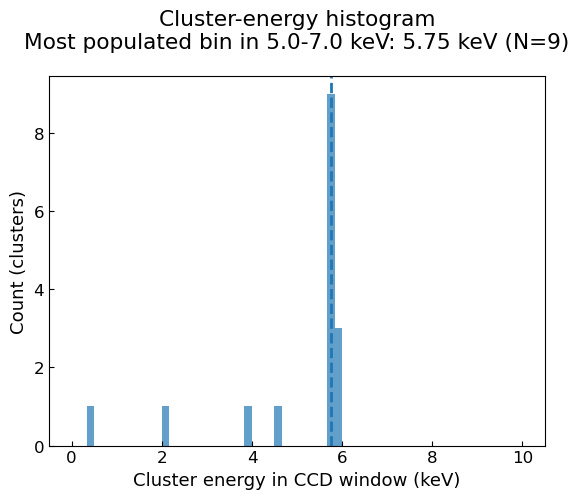

Histogram mode estimate:
  Energy (bin center) = 5.750 keV
  Bin count           = 9


In [108]:
cluster_energies = np.asarray(cluster_E)

# --- histogram settings ---
bins = 60
hist_range = (0.0, 10.0)

counts, bin_edges = np.histogram(
    cluster_energies,
    bins=bins,
    range=hist_range
)

# bin centers
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# --- restrict to desired energy window ---
roi_min, roi_max = 5.0, 7.0
roi_mask = (bin_centers >= roi_min) & (bin_centers <= roi_max)

if not np.any(roi_mask):
    raise RuntimeError("No histogram bins in requested energy range")

# --- find most populated bin ---
roi_counts = counts[roi_mask]
roi_centers = bin_centers[roi_mask]

max_idx = np.argmax(roi_counts)
mode_energy = roi_centers[max_idx]
mode_count = roi_counts[max_idx]

# --- plot ---
plt.figure()
plt.hist(
    cluster_energies,
    bins=bins,
    range=hist_range,
    alpha=0.7
)

plt.axvline(mode_energy, linestyle="--", linewidth=2)

plt.xlabel("Cluster energy in CCD window (keV)")
plt.ylabel("Count (clusters)")
plt.title(
    f"Cluster-energy histogram\n"
    f"Most populated bin in {roi_min}-{roi_max} keV: "
    f"{mode_energy:.2f} keV (N={mode_count})"
)
plt.show()

print("Histogram mode estimate:")
print(f"  Energy (bin center) = {mode_energy:.3f} keV")
print(f"  Bin count           = {mode_count}")


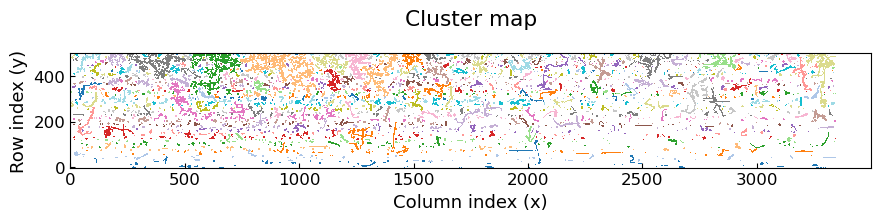

In [109]:
from matplotlib.colors import ListedColormap

H, W = 500, 3500

# label map: NaN = background, integer = cluster ID
labels = np.full((H, W), np.nan, dtype=float)

for cluster_id, (_, row) in enumerate(df2_expanded.iterrows()):
    xs = np.array(row["pixels_x"], dtype=int)
    ys = np.array(row["pixels_y"], dtype=int)

    # keep in-bounds (same as before)
    mask = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
    xs, ys = xs[mask], ys[mask]

    labels[ys, xs] = cluster_id

# ---- colormap: categorical, many colors ----
cmap = plt.cm.get_cmap("tab20", int(np.nanmax(labels)) + 1)
cmap.set_bad("white")  # background

plt.figure(figsize=(9, 4.5))
plt.imshow(
    labels,
    origin="lower",
    cmap=cmap,
    interpolation="none"
)

plt.title("Cluster map")
plt.xlabel("Column index (x)")
plt.ylabel("Row index (y)")

plt.tight_layout()
plt.show()

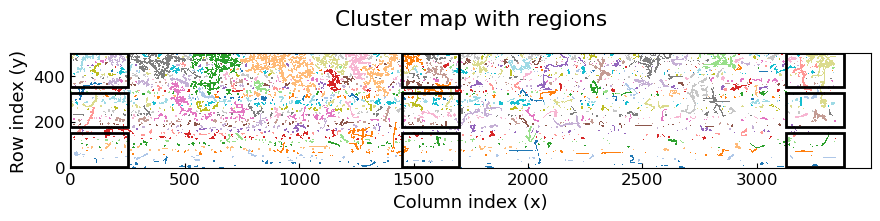

In [27]:
from matplotlib.patches import Rectangle

H, W = 500, 3500

# label map: NaN = background, integer = cluster ID
labels = np.full((H, W), np.nan, dtype=float)

for cluster_id, (_, row) in enumerate(df2_expanded.iterrows()):
    xs = np.array(row["pixels_x"], dtype=int)
    ys = np.array(row["pixels_y"], dtype=int)

    mask = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
    xs, ys = xs[mask], ys[mask]

    labels[ys, xs] = cluster_id

# ---- plot ----
cmap = plt.cm.get_cmap("tab20", int(np.nanmax(labels)) + 1)
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.imshow(labels, origin="lower", cmap=cmap, interpolation="none")

# ----------------------------------------------------
# LEFT COLUMN
# ----------------------------------------------------
x0_L1, x1_L1 = 0, 250
y0_L1, y1_L1 = 0, 150

x0_L2, x1_L2 = 0, 250
y0_L2, y1_L2 = 175, 325

x0_L3, x1_L3 = 0, 250
y0_L3, y1_L3 = 350, 500

# ----------------------------------------------------
# MIDDLE COLUMN
# ----------------------------------------------------
x0_M1, x1_M1 = 1450, 1700
y0_M1, y1_M1 = 0, 150

x0_M2, x1_M2 = 1450, 1700
y0_M2, y1_M2 = 175, 325

x0_M3, x1_M3 = 1450, 1700
y0_M3, y1_M3 = 350, 500

# ----------------------------------------------------
# RIGHT COLUMN
# ----------------------------------------------------
x0_R1, x1_R1 = 3130, 3380
y0_R1, y1_R1 = 0, 150

x0_R2, x1_R2 = 3130, 3380
y0_R2, y1_R2 = 175, 325

x0_R3, x1_R3 = 3130, 3380
y0_R3, y1_R3 = 350, 500

# ----------------------------------------------------
# COLLECT ROIS
# ----------------------------------------------------
roi_boxes = [
    (x0_L1, x1_L1, y0_L1, y1_L1),
    (x0_L2, x1_L2, y0_L2, y1_L2),
    (x0_L3, x1_L3, y0_L3, y1_L3),

    (x0_M1, x1_M1, y0_M1, y1_M1),
    (x0_M2, x1_M2, y0_M2, y1_M2),
    (x0_M3, x1_M3, y0_M3, y1_M3),

    (x0_R1, x1_R1, y0_R1, y1_R1),
    (x0_R2, x1_R2, y0_R2, y1_R2),
    (x0_R3, x1_R3, y0_R3, y1_R3),
]

for x0, x1, y0, y1 in roi_boxes:
    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        linewidth=2,
        edgecolor="black",
        facecolor="none"
    )
    ax.add_patch(rect)

# ----------------------------------------------------

ax.set_title("Cluster map with regions")
ax.set_xlabel("Column index (x)")
ax.set_ylabel("Row index (y)")

plt.tight_layout()
plt.show()
